##### ARTI 560 - Computer Vision  

## Depth Estimation - Exercise  

### Introduction to "Depth Anything"

[Depth Anything](https://github.com/LiheYoung/Depth-Anything) is a modern deep learning model designed for robust **monocular depth estimation.**

![image.png](attachment:image.png)

#### Key Features:
- Works on any image (indoor, outdoor, complex scenes)
- Generalizes well across datasets
- Produces high-quality and smooth depth maps
- Based on large-scale training and transformer architectures

## Pre-trained Models

Depthanything provides three models of varying scales for robust relative depth estimation:

| Model                     | Params |
|--------------------------|--------|
| Depth-Anything-Small     | 24.8M  |
| Depth-Anything-Base      | 97.5M  |
| Depth-Anything-Large     | 335.3M |


### Tasks  

   #### Task 1: Setup

   1. Clone the official [Depth-Anything](https://github.com/LiheYoung/Depth-Anything) repository.

   2. Navigate to the project directory.

   3. Create a new Conda environment with Python 3.10:
      ```bash
      conda create -n depth-anything python=3.10
      conda activate depth-anything
      ```

   4. Install the required dependencies:
      ```bash
      pip install -r requirements.txt
      ```


   #### Task 2: Run Inference  

   1. Select two images of your choice *(you may also use samples from the assets folder).*
   2. Run depth estimation on the first image and generate a grayscale depth map.
   3. Run depth estimation on the second image and generate a color depth map.
   4. Generate the depth map for one video of your choice.
  

### Important Note (SSL Certificate Issue Fix)

If you encounter an SSL certificate error during setup or downloading model weights, use the following workaround:

Add this at the top of your **run.py and run_video.py** files:
```bash
import os
import certifi
os.environ['SSL_CERT_FILE'] = certifi.where()
```

### Submission Requirements  
- Include screenshots showing successful execution of:
   - Grayscale image depth estimation output
   - Color image depth estimation output
   - Video depth estimation output
   - Screenshots of the terminal commands used to generate all three outputs above

In [1]:
%cd /content
!git clone https://github.com/LiheYoung/Depth-Anything.git
%cd /content/Depth-Anything

/content
Cloning into 'Depth-Anything'...
remote: Enumerating objects: 441, done.
remote: Total 441 (delta 0), reused 0 (delta 0), pack-reused 441 (from 1)
Receiving objects: 100% (441/441), 237.90 MiB | 44.20 MiB/s, done.
Resolving deltas: 100% (153/153), done.
/content/Depth-Anything


In [2]:
!pip install -q -r requirements.txt
!pip install -q timm gradio opencv-python matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 305.1/305.1 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 12.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
google-genai 1.68.0 requires websockets<17.0,>=13.0.0, but you have websockets 11.0.3 which is incompatible.

In [3]:
!cp /content/yoga.mp4 /content/Depth-Anything/
!cp /content/walking-persons.mp4 /content/Depth-Anything/

In [4]:
!ffmpeg -y -i walking-persons.mp4 -ss 00:00:01 -frames:v 1 image1.jpg
!ffmpeg -y -i yoga.mp4 -ss 00:00:01 -frames:v 1 image2.jpg

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [5]:
#Grayscale depth للصورة الأولى
!python run.py --encoder vitl --img-path image1.jpg --outdir outputs_gray --grayscale

config.json: 100% 116/116 [00:00<00:00, 698kB/s]
xFormers not available
xFormers not available
pytorch_model.bin: 100% 1.34G/1.34G [00:17<00:00, 78.7MB/s]
Total parameters: 335.32M
100% 1/1 [00:01<00:00,  1.52s/it]


In [6]:
#Color depth للصورة الثانية
!python run.py --encoder vitl --img-path image2.jpg --outdir outputs_color

xFormers not available
xFormers not available
Total parameters: 335.32M
Traceback (most recent call last):
  File "/content/Depth-Anything/run.py", line 60, in <module>
    filenames = os.listdir(args.img_path)
                ^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'image2.jpg'


In [8]:
!ffmpeg -y -i walking-persons.mp4 -ss 00:00:03 -frames:v 1 image2.jpg

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [9]:
#Depth estimation للفيديو
!ffmpeg -y -i walking-persons.mp4 -t 4 depth_video_input.mp4
!python run_video.py --encoder vitl --video-path depth_video_input.mp4 --outdir outputs_video

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [11]:
!python run.py --encoder vitl --img-path image2.jpg --outdir outputs_color

xFormers not available
xFormers not available
Total parameters: 335.32M
100% 1/1 [00:00<00:00,  1.30it/s]


In [12]:
!find outputs_color -type f

outputs_color/image2_img_depth.png


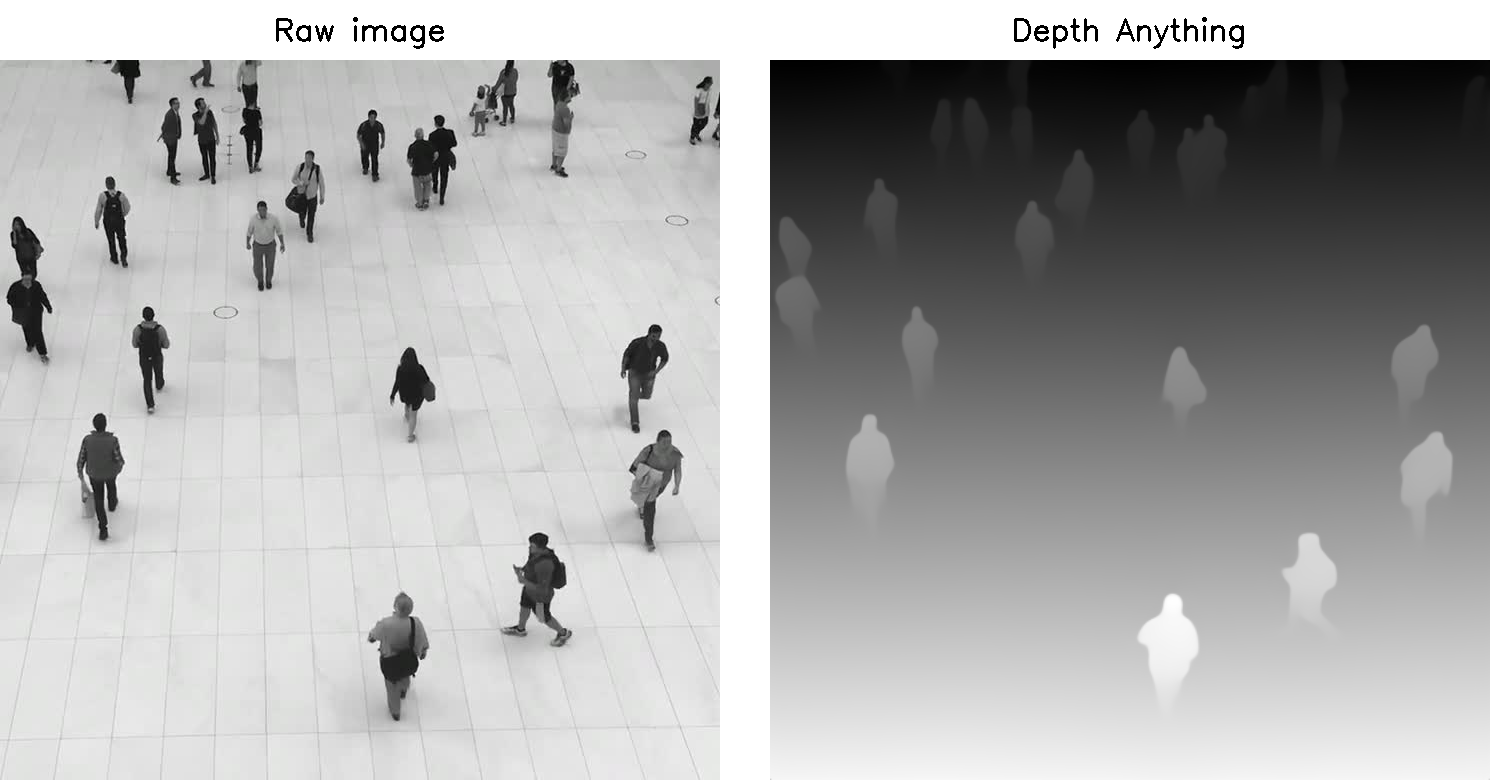

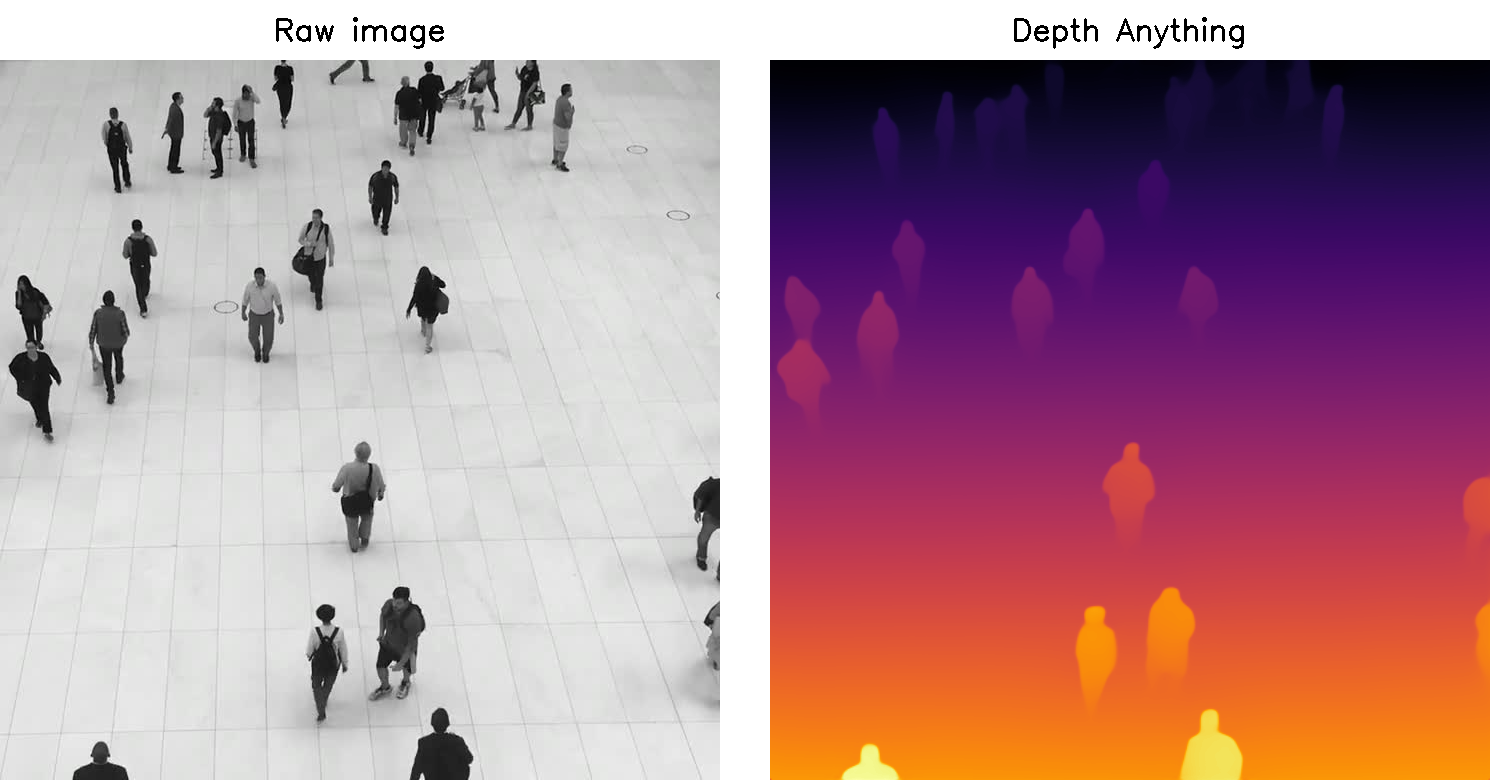

In [13]:
from IPython.display import Image, display

display(Image("outputs_gray/image1_img_depth.png"))
display(Image("outputs_color/image2_img_depth.png"))

In [14]:
%cd /content/Depth-Anything

/content/Depth-Anything


In [15]:
!ffmpeg -y -i walking-persons.mp4 -t 4 depth_video_input.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [17]:
!find outputs_video -type f

outputs_video/depth_video_input_video_depth.mp4


In [20]:
!ffmpeg -y -i outputs_video/depth_video_input_video_depth.mp4 depth_final.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [21]:
from IPython.display import HTML
from base64 import b64encode

mp4 = open("depth_final.mp4", "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width="600" controls>
  <source src="{data_url}" type="video/mp4">
</video>
""")